### Barrier Options: Definition and Classification

A **Barrier Option** is a path-dependent derivative where the payoff depends on whether the underlying asset price $S_t$ reaches or crosses a specific level $H$ (the barrier) during the option's life.

* **Knock-out (Out):** The option is active at inception but expires worthless if the barrier is touched.
* **Knock-in (In):** The option is latent at inception and only becomes a standard vanilla option if the barrier is touched.

#### The 8 Primary Types of Barrier Options

| # | Option Type | Direction | Trigger | Regular / Reverse | Payoff Condition |
|:---|:---|:---|:---|:---|:---|
| 1 | **Call** | **Up** | **Out** | **Reverse** | $(S_T - K)^+$ if $\max(S_t) < H$ ($H > K$) |
| 2 | **Call** | **Up** | **In** | **Reverse** | $(S_T - K)^+$ only if $\max(S_t) \geq H$ ($H > K$) |
| 3 | **Call** | **Down** | **Out** | **Regular** | $(S_T - K)^+$ if $\min(S_t) > H$ ($H < K$) |
| 4 | **Call** | **Down** | **In** | **Regular** | $(S_T - K)^+$ only if $\min(S_t) \leq H$ ($H < K$) |
| 5 | **Put** | **Up** | **Out** | **Regular** | $(K - S_T)^+$ if $\max(S_t) < H$ ($H > K$) |
| 6 | **Put** | **Up** | **In** | **Regular** | $(K - S_T)^+$ only if $\max(S_t) \geq H$ ($H > K$) |
| 7 | **Put** | **Down** | **Out** | **Reverse** | $(K - S_T)^+$ if $\min(S_t) > H$ ($H < K$) |
| 8 | **Put** | **Down** | **In** | **Reverse** | $(K - S_T)^+$ only if $\min(S_t) \leq H$ ($H < K$) |

**In-Out Parity:**
$$\text{Price}_{\text{Vanilla}} = \text{Price}_{\text{Knock-In}} + \text{Price}_{\text{Knock-Out}}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

### Function for the payoff of an Up and Out call 

In [2]:
def uao_call_payoff(S,K,H) :
   # condition: S is between K and H
    # if true: S - K
    # if false: 0
    return np.where((S > K) & (S < H), S - K, 0)

    #if we use classical if and >, <, inequalities, we will have an error when plotting
    #ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

### Implementation 

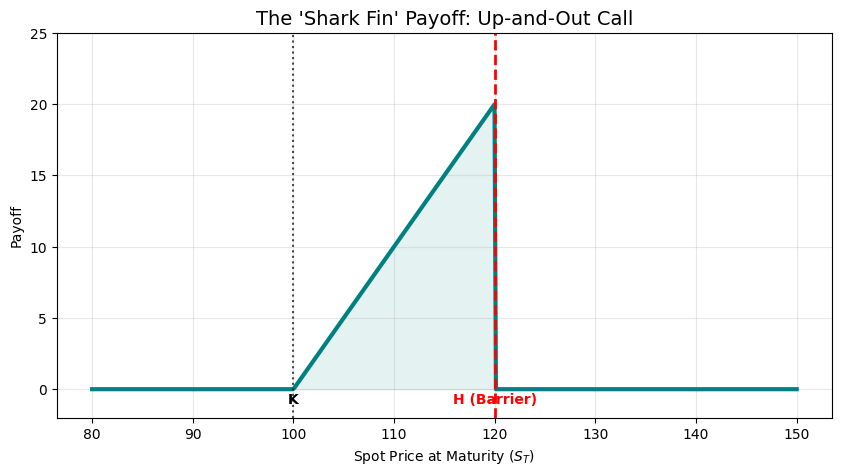

In [3]:
# --- Parameters ---
K = 100    # Strike
H = 120    # Barrier (The "Cliff")
S = np.linspace(80, 150, 500)

payoff=uao_call_payoff(S,K,H) 

plt.figure(figsize=(10, 5))
plt.plot(S, payoff, color='teal', lw=3, label='UAO Call Payoff')

# Adding the visual markers
plt.axvline(K, color='black', linestyle=':', alpha=0.7)
plt.text(K, -1, 'K', ha='center', fontweight='bold')

plt.axvline(H, color='red', linestyle='--', lw=2)
plt.text(H, -1, 'H (Barrier)', ha='center', color='red', fontweight='bold')

# Styling the "Shark"
plt.fill_between(S, payoff, color='teal', alpha=0.1)
plt.title("The 'Shark Fin' Payoff: Up-and-Out Call", fontsize=14)
plt.xlabel("Spot Price at Maturity ($S_T$)")
plt.ylabel("Payoff")
plt.grid(True, alpha=0.3)
plt.ylim(-2, 25)


plt.show()

### Up-and-Out (UAO) Call Pricing: Reiner-Rubinstein Formula

For a **Reverse Barrier** option where the barrier is above the strike ($H > K$), the Present Value (PV) is derived using the **Reflection Principle**. The price is effectively the value of a vanilla call minus the value of the "knock-in" component.

#### 1. The Pricing Equation
The price of the UAO Call is given by:
$$V_{UAO} = (A - B) - (C - D)$$

Where:
* **(A - B)** represents the standard **Black-Scholes Vanilla Call**.
* **(C - D)** represents the cost of the **Up-and-In Call** (the probability of hitting the barrier).

#### 2. The Components
The terms are defined as follows:

$$A = S e^{-qT} \Phi(d_1)$$
$$B = K e^{-rT} \Phi(d_2)$$
$$C = S e^{-qT} (H/S)^{2\lambda} \Phi(y_1)$$
$$D = K e^{-rT} (H/S)^{2\lambda - 2} \Phi(y_2)$$



#### 3. Parameter Definitions
To implement this in Python, you need the following auxiliary variables:

* **Drift/Volatility Ratio ($\lambda$):** $$\lambda = \frac{r - q + \frac{\sigma^2}{2}}{\sigma^2}$$
* **Standard Terms ($d_1, d_2$):**
    $$d_1 = \frac{\ln(S/K) + (r - q + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$
* **Mirror Terms ($y_1, y_2$):**
    $$y_1 = \frac{\ln(H^2 / (S \cdot K)) + (r - q + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, \quad y_2 = y_1 - \sigma\sqrt{T}$$

#### 4. The Reflection Principle Intuition
Mathematically, reaching the barrier $H$ from below is equivalent to the probability of a "reflected" Brownian Motion reaching a certain strike from above. This is why the terms $C$ and $D$ look like "warped" versions of the standard call, scaled by the distance to the barrier $(H/S)$.

---

### Key Behavioral 
As $S \to H$:
1.  **Price Convergence:** $V_{UAO}$ must approach **0** (the "cliff").
2.  **Vega Reversal:** Unlike a vanilla call, increasing $\sigma$ increases the magnitude of terms $C$ and $D$ faster than $A$ and $B$, causing the total price to drop. This results in **Negative Vega**.

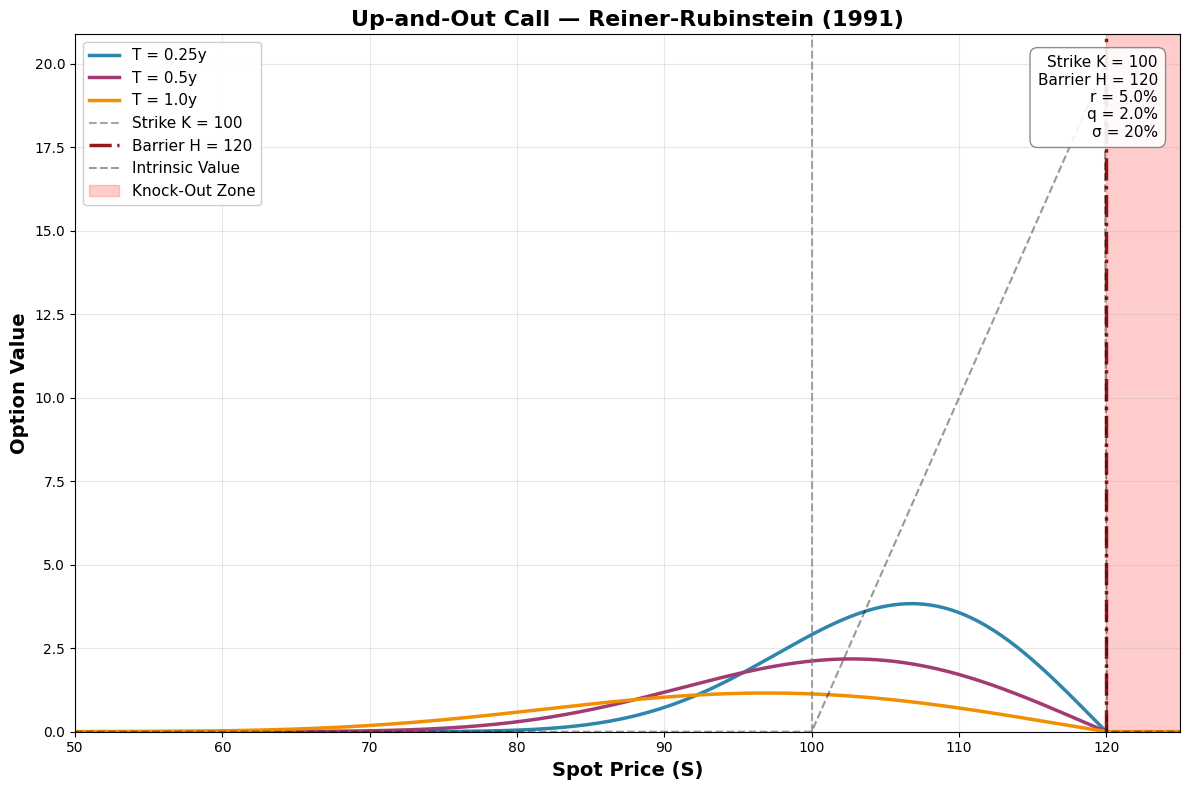

In [4]:
def reiner_rubinstein_up_out_call(S, K, H, T, r, q, sigma, rebate=0):
    """
    Up-and-Out Call using Reiner-Rubinstein (1991) closed-form solution.
    
    Parameters:
    - S: Spot price
    - K: Strike price  
    - H: Barrier level (H > S for up barrier)
    - T: Time to maturity (years)
    - r: Risk-free rate
    - q: Dividend yield
    - sigma: Volatility
    - rebate: Rebate paid if barrier is hit (default 0)
    
    Returns:
    - Up-and-Out Call price
    """
    S = np.atleast_1d(np.asarray(S, dtype=float))
    prices = np.zeros_like(S)
    
    # Already knocked out
    knocked = S >= H
    prices[knocked] = rebate * np.exp(-r * T)
    
    active = ~knocked
    if not np.any(active):
        return prices if len(prices) > 1 else prices[0]
    
    S_a = S[active]
    
    # Common parameters
    mu = (r - q - 0.5 * sigma**2) / sigma**2
    lambda_ = np.sqrt(mu**2 + 2 * r / sigma**2)
    
    z = np.log(H / S_a) / (sigma * np.sqrt(T)) + lambda_ * sigma * np.sqrt(T)
    
    # x1, x2, y1, y2 parameters
    x1 = np.log(S_a / K) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    x2 = np.log(S_a / H) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    y1 = np.log(H**2 / (S_a * K)) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    y2 = np.log(H / S_a) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    
    # Components A, B, C, D, E, F
    phi = 1  # Call
    eta = -1  # Up barrier
    
    # A: Standard call/put component
    A = phi * S_a * np.exp(-q * T) * norm.cdf(phi * x1) \
        - phi * K * np.exp(-r * T) * norm.cdf(phi * x1 - phi * sigma * np.sqrt(T))
    
    # B: Adjusted for barrier at H
    B = phi * S_a * np.exp(-q * T) * norm.cdf(phi * x2) \
        - phi * K * np.exp(-r * T) * norm.cdf(phi * x2 - phi * sigma * np.sqrt(T))
    
    # C: Reflected component
    C = phi * S_a * np.exp(-q * T) * (H / S_a)**(2 * (mu + 1)) * norm.cdf(eta * y1) \
        - phi * K * np.exp(-r * T) * (H / S_a)**(2 * mu) * norm.cdf(eta * y1 - eta * sigma * np.sqrt(T))
    
    # D: Reflected adjusted component
    D = phi * S_a * np.exp(-q * T) * (H / S_a)**(2 * (mu + 1)) * norm.cdf(eta * y2) \
        - phi * K * np.exp(-r * T) * (H / S_a)**(2 * mu) * norm.cdf(eta * y2 - eta * sigma * np.sqrt(T))
    
    # E, F: Rebate components
    E = rebate * np.exp(-r * T) * (
        norm.cdf(eta * x2 - eta * sigma * np.sqrt(T)) 
        - (H / S_a)**(2 * mu) * norm.cdf(eta * y2 - eta * sigma * np.sqrt(T))
    )
    
    F = rebate * (
        (H / S_a)**(mu + lambda_) * norm.cdf(eta * z)
        + (H / S_a)**(mu - lambda_) * norm.cdf(eta * z - 2 * eta * lambda_ * sigma * np.sqrt(T))
    )
    
    # Up-and-Out Call (K < H): A - B + C - D + E + F
    # Up-and-Out Call (K >= H): E + F (worthless except rebate)
    
    case1 = K < H
    if case1:
        prices[active] = A - B + C - D + E + F
    else:
        prices[active] = E + F
    
    # Ensure non-negative
    prices = np.maximum(prices, 0)
    
    return prices if len(prices) > 1 else prices[0]


# ============== PLOTTING ==============

# Parameters
K = 100        # Strike price
H = 120        # Barrier level
r = 0.05       # Risk-free rate
q = 0.02       # Dividend yield
sigma = 0.20   # Volatility

# Spot price range
S = np.linspace(50, 125, 500)

# Multiple maturities
maturities = [0.25, 0.5, 1.0]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot for each maturity
for T, color in zip(maturities, colors):
    prices = reiner_rubinstein_up_out_call(S, K, H, T, r, q, sigma)
    ax.plot(S, prices, color=color, linewidth=2.5, label=f'T = {T}y')

# Reference lines
ax.axvline(x=K, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Strike K = {K}')
ax.axvline(x=H, color='darkred', linestyle='-.', linewidth=2.5, alpha=0.9, label=f'Barrier H = {H}')

# Intrinsic value (knocked out above H)
intrinsic = np.maximum(S - K, 0)
intrinsic[S >= H] = 0
ax.plot(S, intrinsic, 'k--', linewidth=1.5, alpha=0.4, label='Intrinsic Value')

# Shade knock-out region
ax.axvspan(H, 125, alpha=0.2, color='red', label='Knock-Out Zone')

# Styling
ax.set_xlabel('Spot Price (S)', fontsize=14, fontweight='bold')
ax.set_ylabel('Option Value', fontsize=14, fontweight='bold')
ax.set_title('Up-and-Out Call — Reiner-Rubinstein (1991)', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='-')
ax.set_xlim(50, 125)
ax.set_ylim(0, None)

# Parameter box
param_text = f'Strike K = {K}\nBarrier H = {H}\nr = {r:.1%}\nq = {q:.1%}\nσ = {sigma:.0%}'
ax.text(0.98, 0.97, param_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.show()

<>:31: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:31: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/z2/8m1s5xtd2856rcnbnsk5jmr00000gn/T/ipykernel_26132/2320310403.py:31: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.ylabel("Vega ($\partial V / \partial \sigma$)", fontsize=12)


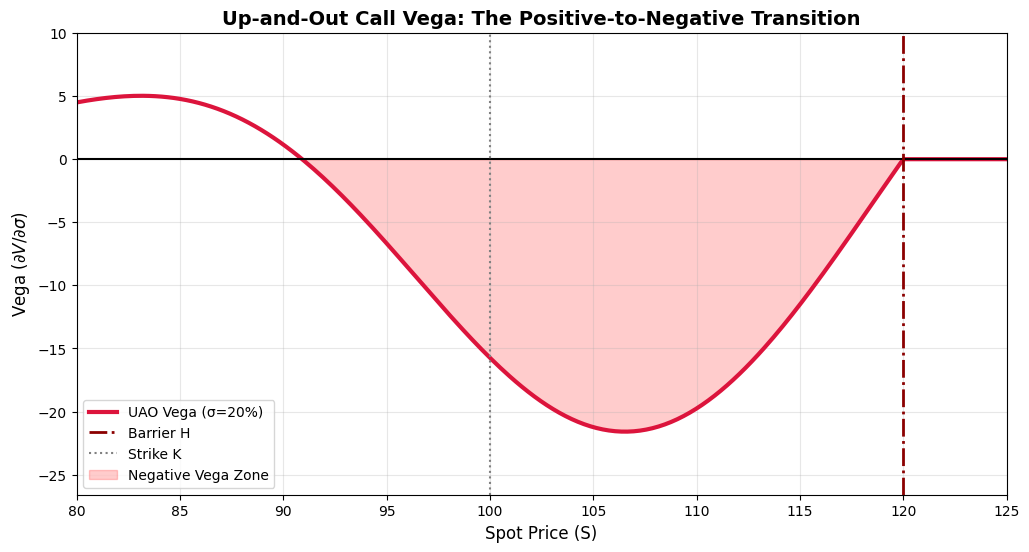

In [5]:


def calculate_uao_vega(S, K, H, T, r, q, sigma, epsilon=0.01):
    # Bump Volatility up and down
    price_plus = reiner_rubinstein_up_out_call(S, K, H, T, r, q, sigma + epsilon)
    price_minus = reiner_rubinstein_up_out_call(S, K, H, T, r, q, sigma - epsilon)
    
    # Finite difference Vega
    return (price_plus - price_minus) / (2 * epsilon)

# --- Parameters ---
sigma_val = 0.20
vega_values = calculate_uao_vega(S, K, H, T=0.5, r=0.05, q=0.02, sigma=sigma_val)

# --- Plotting the Vega ---
plt.figure(figsize=(12, 6))
plt.plot(S, vega_values, color='crimson', lw=3, label=f'UAO Vega (σ={sigma_val:.0%})')

# Visual Cues
plt.axhline(0, color='black', lw=1.5) # The Zero-Crossing
plt.axvline(H, color='darkred', ls='-.', lw=2, label='Barrier H')
plt.axvline(K, color='gray', ls=':', label='Strike K')

# Highlight the Negative Vega Zone
plt.fill_between(S, vega_values, 0, where=(vega_values < 0), color='red', alpha=0.2, label='Negative Vega Zone')

# Scale Fix: Focus on the flip
plt.ylim(min(vega_values) - 5, max(vega_values) + 5)
plt.xlim(80, 125)

plt.title("Up-and-Out Call Vega: The Positive-to-Negative Transition", fontsize=14, fontweight='bold')
plt.xlabel("Spot Price (S)", fontsize=12)
plt.ylabel("Vega ($\partial V / \partial \sigma$)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Delta 

### Far from Barrier (S << H)
- **Positive delta** similar to vanilla call when in-the-money (S > K)
- Behaves like a regular call option
- Delta increases as spot moves deeper ITM

### Approaching Barrier from Below (S → H⁻)
- **Delta spikes to -∞** (negative infinity)
- **Why?** As S approaches H, a tiny increase knocks out the option
  - Option value drops discontinuously from positive to ~0 (or rebate)
  - This creates massive negative sensitivity
- **Shorter maturities**: Sharper, more dramatic spike
- **Longer maturities**: More gradual transition (time to "escape" barrier)

### At or Above Barrier (S ≥ H)
- **Delta = 0** (option is knocked out)
- No sensitivity to spot price changes
- Option is worthless (or worth rebate value)

## Key Insights

1. **Discontinuity at barrier** creates the infinity behavior
2. **Negative delta near H**: Counterintuitive for a call, but rational
   - Buying stock as S → H would be a disaster (instant knockout)
   - Delta hedging requires **short position** near barrier
3. **Time dependency**: Shorter T → more extreme delta behavior
4. **Hedging challenge**: Delta hedge ratio becomes unstable near H

### Note
The spike to -∞ is a theoretical result. In practice:
- Transaction costs and discrete hedging prevent infinite positions
- Risk managers often stop delta hedging very close to barriers

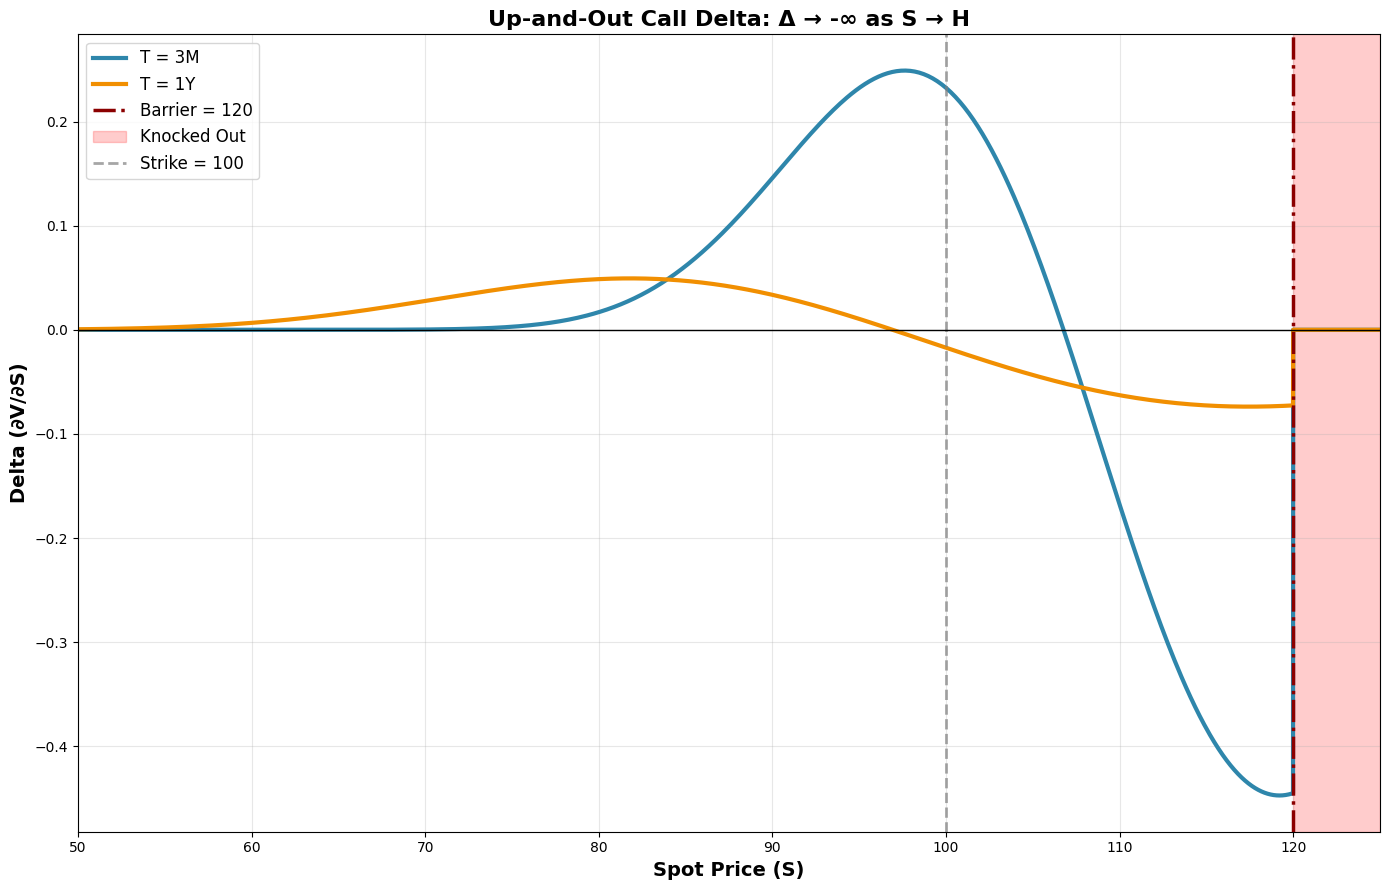

In [6]:
# ============== DELTA CALCULATION ==============

def delta_up_out_call(S, K, H, T, r, q, sigma):
    """
    Delta = (V(S+h) - V(S)) / h
    """
    h = 0.01
    V1 = reiner_rubinstein_up_out_call(S, K, H, T, r, q, sigma)
    V2 = reiner_rubinstein_up_out_call(S + h, K, H, T, r, q, sigma)
    return (V2 - V1)/h


# ============== PLOTTING ==============

# Parameters
K = 100
H = 120
r = 0.05
q = 0.02
sigma = 0.20

# Spot prices (dense near barrier)
S = np.concatenate([
    np.linspace(50, 115, 500),
    np.linspace(115, 119.99, 3000),
    np.linspace(120, 125, 50)
])

# Calculate deltas for two maturities
delta_3m = delta_up_out_call(S, K, H, 0.25, r, q, sigma)
delta_1y = delta_up_out_call(S, K, H, 1.0, r, q, sigma)

# Plot
plt.figure(figsize=(14, 9))

plt.plot(S, delta_3m, color='#2E86AB', linewidth=3, label='T = 3M')
plt.plot(S, delta_1y, color='#F18F01', linewidth=3, label='T = 1Y')

# Barrier and knockout zone
plt.axvline(x=H, color='darkred', linestyle='-.', linewidth=2.5, label=f'Barrier = {H}')
plt.axvspan(H, 125, alpha=0.2, color='red', label='Knocked Out')

# Strike line
plt.axvline(x=K, color='gray', linestyle='--', linewidth=2, alpha=0.7, label=f'Strike = {K}')
plt.axhline(y=0, color='black', linewidth=1)

# Labels
plt.xlabel('Spot Price (S)', fontsize=14, fontweight='bold')
plt.ylabel('Delta (∂V/∂S)', fontsize=14, fontweight='bold')
plt.title('Up-and-Out Call Delta: Δ → -∞ as S → H', fontsize=16, fontweight='bold')
plt.legend(loc='upper left', fontsize=12)
plt.grid(alpha=0.3)
plt.xlim(50, 125)

plt.tight_layout()
plt.show()

Blue curves and yellow curves should go to $-\infty$ near barrier.

## Gamma of Up-and-Out Call Options

#### Before Barrier (S < H)
- Delta is plunging from moderate negative values to -∞
- **Gamma spikes to +∞** as S → H⁻ (Delta changes explosively near the barrier)
- **Shorter maturities**: More extreme gamma spike

#### At/After Barrier (S ≥ H)
- Option knocked out
- **Gamma = 0** (no sensitivity, option is dead)

### Hedging Implications

**Massive gamma near barrier = delta hedge becomes unstable:**
- Small moves in S require huge position adjustments
- Transaction costs explode
- Many traders **stop delta hedging** very close to barriers
- "Gamma risk" is the main concern for barrier options

### Key Insight
The barrier creates a **discontinuity in delta**, which produces an **infinite gamma spike** just before knockout. This makes these options extremely difficult to hedge dynamically.

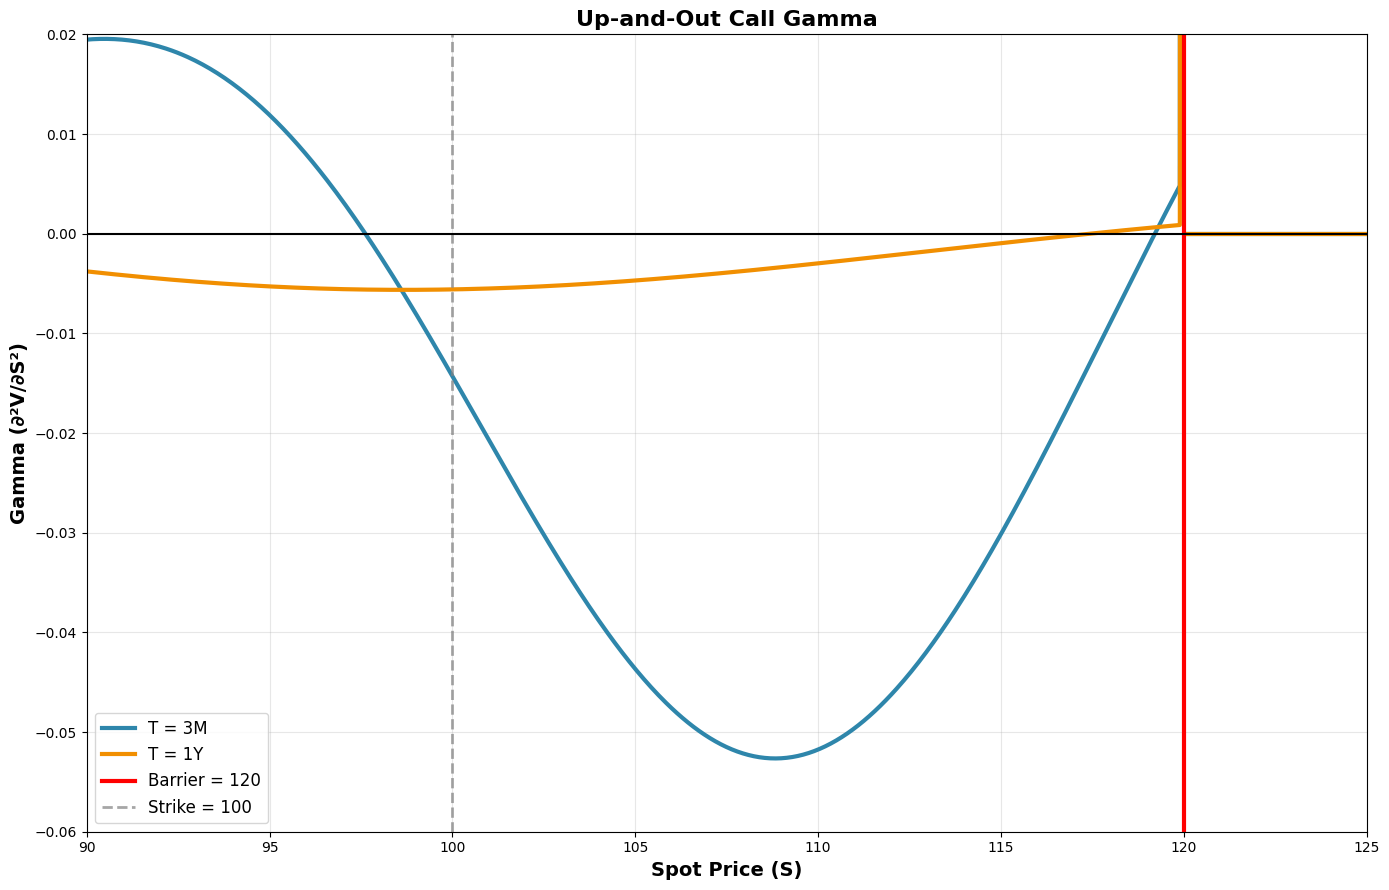

In [7]:

# ==========================================
# # 1. HELPER FUNCTIONS
# ==========================================

def gamma_up_out_call(S, K, H, T, r, q, sigma):
    """
    Calculates Gamma using finite differences of Delta.
    Gamma = (Delta(S+h) - Delta(S-h)) / (2h)
    Note: Requires 'delta_up_out_call' to be defined in a previous cell.
    """
    h = 0.1 # Step size for num diff
    delta_plus = delta_up_out_call(S + h, K, H, T, r, q, sigma)
    delta_minus = delta_up_out_call(S - h, K, H, T, r, q, sigma)
    return (delta_plus - delta_minus) / (2 * h)

# ==========================================
# 2. PARAMETERS & GRID SETUP
# ==========================================

K = 100     # Strike Price
H = 120     # Barrier Price
r = 0.05    # Risk-free Rate
q = 0.02    # Dividend Yield
sigma = 0.20 # Volatility

# Create Spot Price Grid (S)
# We concatenate three ranges to ensure high resolution near the barrier
# and to include the region AFTER the barrier (where Gamma is 0)
S = np.concatenate([
    np.linspace(80, 115, 700),      # Regular Grid
    np.linspace(115, 119.9, 2000),  # Dense Grid near Barrier (Pre-knockout)
    np.linspace(120.1, 130, 200)    # Post-Barrier Grid (Knocked-out)
])

# ==========================================
# 3. CALCULATION
# ==========================================

gamma_3m = gamma_up_out_call(S, K, H, 0.25, r, q, sigma)
gamma_1y = gamma_up_out_call(S, K, H, 1.0, r, q, sigma)

# ==========================================
# 4. PLOTTING
# ==========================================

fig, ax = plt.subplots(figsize=(14, 9))

# -- Plotting Trick --
# We mask the data to plot the "Active" region separately from the "Knocked-out"
# region. This prevents matplotlib from drawing a vertical line connecting the 
# spike (infinity) to zero at the barrier.

mask_active = S < H  # Option is alive
mask_knocked = S > H # Option is dead (Gamma = 0)

# Plot Active Region (S < H)
ax.plot(S[mask_active], gamma_3m[mask_active], color='#2E86AB', lw=3, label='T = 3M')
ax.plot(S[mask_active], gamma_1y[mask_active], color='#F18F01', lw=3, label='T = 1Y')

# Plot Knocked-out Region (S > H) - ensuring we see the 0 line
ax.plot(S[mask_knocked], gamma_3m[mask_knocked], color='#2E86AB', lw=3)
ax.plot(S[mask_knocked], gamma_1y[mask_knocked], color='#F18F01', lw=3)

# -- Styling --

# Barrier Line (Red & Visible)
ax.axvline(x=H, color='red', linestyle='-', lw=3, label=f'Barrier = {H}')

# Strike Line & Zero Axis
ax.axvline(x=K, color='gray', linestyle='--', lw=2, alpha=0.7, label=f'Strike = {K}')
ax.axhline(y=0, color='black', lw=1.5)

# Labels & Legend
ax.set_xlabel('Spot Price (S)', fontsize=14, fontweight='bold')
ax.set_ylabel('Gamma (∂²V/∂S²)', fontsize=14, fontweight='bold')
ax.set_title('Up-and-Out Call Gamma', fontsize=16, fontweight='bold')
ax.legend(loc='lower left', fontsize=12)
ax.grid(alpha=0.3)

# -- Zoom Settings --
# Focus on the negative gamma region and the transition to zero
ax.set_xlim(90, 125) 
ax.set_ylim(-0.06, 0.02) 
ax.set_yticks(np.arange(-0.06, 0.021, 0.01)) # Ticks every 0.01

plt.tight_layout()
plt.show()